In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes', 'gymnasium']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact'), 'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Dynamic Programming

When the state space, action space, transition kernel, and reward are known, an optimal policy can be computed by *dynamic programming* [@BellmanDPBook]. The Bellman equations decompose each state's value into its immediate reward and the values of possible successor states. For discounted finite MDPs, the associated Bellman operator is a contraction, which yields a unique solution and a convergent iterative algorithm. We apply these results to FrozenLake and compare the optimal policy with the shortest-path policy.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import gymnasium as gym
import numpy as np

## Policies and Value Functions

### State Values and Action Values

A *stochastic policy* $\pi(a \mid s)$ (policy for short) is a conditional distribution over the actions $a \in \mathcal{A}$ given the state $s \in \mathcal{S}$: at some state of the lake the probabilities of *left*, *down*, *right*, *up* might be $(0.4, 0.2, 0.1, 0.3)$. A *deterministic* policy puts all its probability on a single action, which we then call $\pi(s)$; more generally we abbreviate the distribution $\pi(\cdot \mid s)$ as $\pi(s)$.

For a fixed policy, an agent starting from $s_0$ samples $a_t \sim \pi(s_t)$, moves to $s_{t+1} \sim P(\cdot \mid s_t, a_t)$, and traces out the trajectory $\tau$ of that section. Different runs give different trajectories, so the natural score is the average,

$$V^\pi(s_0) = E_{a_t \sim \pi(s_t),\ s_{t+1} \sim P(\cdot \mid s_t, a_t)} \Big[ \sum_{t=0}^\infty \gamma^t r(s_t, a_t) \Big],$$

the *value function* of $\pi$. Because the start state is arbitrary, $V^\pi$ assigns a number to every state. The algorithms below operate on this value table.

In implementations, it is often useful to maintain a closely related quantity called the "action value" function. This is defined as the average *return* of a trajectory that begins at $s_0$ but whose first-stage action is fixed to be $a_0$

$$Q^\pi(s_0, a_0) = r(s_0, a_0) + E_{a_t \sim \pi(s_t),\ s_{t+1} \sim P(\cdot \mid s_t, a_t)} \Big[ \sum_{t=1}^\infty \gamma^t r(s_t, a_t) \Big],$$

note that the summation inside the expectation is from $t=1,\ldots, \infty$ because the reward of the first stage is fixed in this case: act as you must for one step, then follow the policy forever.

### The Identity Linking $V$ and $Q$

The value function averages the action-value function over the policy's first action:

$$V^\pi(s) = \sum_{a \in \mathcal{A}} \pi(a \mid s)\, Q^\pi(s, a);\ \textrm{for all } s \in \mathcal{S}.$$

Conversely, the first stage of $Q^\pi$ is explicit: $Q^\pi(s, a) = r(s, a) + \gamma \sum_{s'} P(s' \mid s, a) V^\pi(s')$. Because $V^\pi(s)$ is a convex combination of $Q^\pi(s, a)$ over actions, $\max_a Q^\pi(s, a) \geq V^\pi(s)$. The inequality is strict when the policy assigns positive probability to actions below the maximum. Policy-improvement methods increase probability on actions with positive advantage.

### The Advantage Function

The *advantage* of an action is its value relative to the policy's average value at that state,

$$
A^\pi(s, a) = Q^\pi(s, a) - V^\pi(s), \qquad E_{a \sim \pi(s)} \big[ A^\pi(s, a) \big] = 0,
$$

The zero-mean identity follows directly from the relation between $V^\pi$ and $Q^\pi$. A positive advantage indicates that action $a$ performs better than the policy's current average at state $s$. Later policy-gradient methods estimate or approximate this quantity when updating the policy.

## The Bellman Equations

The Markov assumption converts the infinite trajectory sums above into local recursive equations.

### The Expectation Form

Separate a trajectory after its first transition. The first part contains action $a_0$, reward $r(s_0,a_0)$, and next state $s_1$; the remainder is the trajectory beginning at $s_1$. By the Markov property, the expected return of the remainder depends on the past only through $s_1$ and equals $V^\pi(s_1)$. The value at $s_0$ is therefore the expected immediate reward plus the discounted expected value of the next state:

$$V^\pi(s_0) = E_{a_0 \sim \pi(s_0)} \Big[ r(s_0, a_0) + \gamma\ E_{s_1 \sim P(s_1 \mid s_0, a_0)} \Big[ V^\pi(s_1) \Big] \Big].$$

This decomposition is the basis of dynamic programming and of the Bellman
updates used by many reinforcement-learning algorithms. The outer
expectation averages over the policy's choice of $a_0$; the inner one
averages over the environment's next state $s_1$ conditional on that
action. For finite state and action spaces, we can write these expectations
as sums:

$$V^\pi(s) = \sum_{a \in \mathcal{A}} \pi(a \mid s) \Big[ r(s,  a) + \gamma\  \sum_{s' \in \mathcal{S}} P(s' \mid s, a) V^\pi(s') \Big];\ \textrm{for all } s \in \mathcal{S}.$$

The same decomposition applies to a trajectory beginning at any state $s\in\mathcal{S}$. Conditioning additionally on the first action gives the corresponding equation for the action value:

$$Q^\pi(s, a) = r(s, a) + \gamma \sum_{s' \in \mathcal{S}} P(s' \mid s, a) \sum_{a' \in \mathcal{A}} \pi(a' \mid s')\ Q^\pi(s', a');\ \textrm{ for all } s \in \mathcal{S}, a \in \mathcal{A}.$$

This version is the analog of the equation for the action value function. These are the *Bellman expectation equations*: for a fixed policy, the equation is a system of $|\mathcal{S}|$ linear equations in $|\mathcal{S}|$ unknowns. The infinite horizon has disappeared into the recursion.

### The Optimality Equation

An optimal policy maximizes the value function. We may write $\pi^* = \mathrm{argmax}_\pi V^\pi(s_0)$ for a chosen start state. For a discounted finite MDP, however, one stationary deterministic policy is optimal from every state.

**Proposition (a uniformly optimal policy exists).** *In a finite MDP with discount $0 \leq \gamma < 1$ there is a deterministic, stationary policy $\pi^*$ that is optimal at every state simultaneously: $V^{\pi^*}(s) \geq V^\pi(s)$ for all $s \in \mathcal{S}$ and all policies $\pi$, including stochastic and history-dependent ones* [@Puterman.1994].

The intuition is the two-stage decomposition itself: what is best at a state does not depend on how the agent arrived there, so the best behaviors from different starts never conflict; and randomizing cannot help, since a convex combination of action values never exceeds their maximum. Write $V^* \equiv V^{\pi^*}$ and $Q^* \equiv Q^{\pi^*}$, and insert $\pi^*$ into the equation: the policy assigns probability only to maximizing actions, so the average becomes a maximum,

$$V^*(s) = \max_{a \in \mathcal{A}} \Big[ r(s, a) + \gamma\ \sum_{s' \in \mathcal{S}} P(s' \mid s, a)\ V^*(s') \Big];\ \textrm{for all } s \in \mathcal{S}.$$

This is the *Bellman optimality equation*
[@BellmanDPPaper; @BellmanDPBook]. Its optimal-substructure property says
that after any first transition, the continuation must itself be optimal
from the resulting state. Unlike the expectation form, it mentions no
policy: it is an equation in the unknown table $V^*$ and is nonlinear
because of the maximum. Given its solution, a maximizing action follows
from one model-based lookahead:

$$\pi^*(s) = \underset{a \in \mathcal{A}}{\mathrm{argmax}} \Big[ r(s, a) + \gamma \sum_{s' \in \mathcal{S}} P(s' \mid s, a)\ V^*(s') \Big].$$

For a deterministic policy, the optimal action at state $s$ maximizes its immediate reward $r(s, a)$ plus the discounted expected value over possible next states $s'$. The next state $s'$ is averaged according to the transition model. The action-value version of the equation is

$$Q^*(s, a) = r(s, a) + \gamma \sum_{s' \in \mathcal{S}} P(s' \mid s, a) \max_{a' \in \mathcal{A}} Q^*(s', a'),$$

The distinction matters for that section: extracting
$\pi^*(s) = \mathrm{argmax}_a Q^*(s, a)$ from $Q^*$ needs no additional
model, whereas extraction from $V^*$ via the equation uses
$P$ and $r$ in the lookahead.

### Backup Diagrams

The four equations share a common structure: the value at a root is computed from values one step below it. Such updates are called *backups*; the figure illustrates them. The sampled update in that section replaces the expectation over next states with the single observed transition shown in blue in the rightmost diagram.

![Backup diagrams. Open circles are states, filled dots are state-action pairs, and each diagram shows how the value at the root is assembled from the values one step below it. Left to right: (a) the value function averages over the policy's actions and the environment's next states; (b) the action-value function fixes the first action and averages afterwards; (c) the optimality operator replaces the average over actions by a maximum, drawn as the arc; (d) a sampled backup cannot take the environment's average, so it uses the single observed transition, in blue, and keeps the maximum at the next state.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-backups.svg)

## Convergence via Contraction

The Bellman optimality equation defines $V^*$ implicitly. To compute it, read the equation as a map: the *Bellman optimality operator* $T$ acts on any table $V: \mathcal{S} \to \mathbb{R}$ by

$$(TV)(s) = \max_{a \in \mathcal{A}} \Big[ r(s, a) + \gamma \sum_{s' \in \mathcal{S}} P(s' \mid s, a)\ V(s') \Big],$$

so that the equation says exactly $V^* = TV^*$: the optimal value function is a *fixed point* of $T$. The operator $T$ contracts distances in the sup norm.

### The Contraction Proposition

Distance between value functions is measured in the sup norm $\|V\|_\infty = \max_{s} |V(s)|$, the largest disagreement at any state.

**Proposition (the Bellman operator is a $\gamma$-contraction).** *For any two tables $V, V': \mathcal{S} \to \mathbb{R}$,*

$$\|TV - TV'\|_\infty \leq \gamma\, \|V - V'\|_\infty.$$

**Proof.** Fix $s$ and write $f(a)$ and $g(a)$ for the bracketed terms in $(TV)(s)$ and $(TV')(s)$. For every $a$, $|f(a) - g(a)| = \gamma\, |\sum_{s'} P(s' \mid s, a)(V(s') - V'(s'))| \leq \gamma \|V - V'\|_\infty$, because the probabilities are non-negative and sum to one. The difference between two maxima is bounded by the largest input difference, $|\max_a f(a) - \max_a g(a)| \leq \max_a |f(a) - g(a)|$, so $|(TV)(s) - (TV')(s)| \leq \gamma \|V - V'\|_\infty$ for every $s$. $\blacksquare$

The contraction permits an application of Banach's fixed-point theorem. It implies that the Bellman operator has a unique fixed point and that repeated application converges to it. the figure illustrates the resulting nested error bounds.

![Value iteration converges because the Bellman operator is a contraction. (a) A two-state MDP in the plane of its value functions: the sup-norm balls of radius $\gamma^k r_0$ around $V^*$ are nested squares, and each backup lands the iterate strictly inside the next smaller one. (b) The same statement measured on the slippery lake at $\gamma = 0.95$, starting from $V_0 = 0$: the distance to $V^*$ never exceeds the $\gamma^k$ guarantee, the dashed line, and here shrinks somewhat faster.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-contraction.svg)

### Consequences of Contraction

The contraction has four consequences. First, the fixed point is unique: if $V$ and $V'$ are fixed points, then $\|V-V'\|_\infty\leq\gamma\|V-V'\|_\infty$, which for $\gamma<1$ implies $V=V'$. Second, value iteration converges from any initial $V_0$ at a geometric rate:

$$\|V_k - V^*\|_\infty = \|TV_{k-1} - TV^*\|_\infty \leq \gamma\, \|V_{k-1} - V^*\|_\infty \leq \cdots \leq \gamma^k\, \|V_0 - V^*\|_\infty,$$

Thus accuracy $\varepsilon$ is reached after at most $\log(\|V_0-V^*\|_\infty/\varepsilon)/\log(1/\gamma)$ sweeps. For $\gamma$ near one, the denominator is approximately $1-\gamma$, connecting the rate to the effective horizon of that section. Third, the successive differences provide a computable stopping rule:

$$\|V_k - V^*\|_\infty \leq \frac{\gamma}{1 - \gamma}\, \|V_k - V_{k-1}\|_\infty,$$

The right-hand side depends only on consecutive iterates. Fourth, when $\gamma=1$ the operator is no longer a strict contraction, so uniqueness and convergence do not follow from this argument. Some episodic undiscounted problems still converge, but the general guarantee is absent. Replacing the maximum by an expectation under a fixed policy gives the policy-evaluation operator $T^\pi$, which is a contraction by the same proof and has fixed point $V^\pi$ [@Puterman.1994; @Bertsekas.2025].

## Value Iteration, Policy Evaluation and Policy Iteration

Repeated application of the Bellman operator gives value iteration. We apply it to the slippery FrozenLake model from that section:

In [2]:
gamma = 0.95
LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3
env = gym.make('FrozenLake-v1', is_slippery=True)
mdp = d2l.TabularMDP.from_gym(env, gamma)

### Value Iteration

Iterate the operator: initialize $V_0$ arbitrarily (we use zeros) and sweep

$$V_{k+1}(s) = \max_{a \in \mathcal{A}} \Big[ r(s, a) + \gamma\ \sum_{s' \in \mathcal{S}} P(s' \mid s, a)\ V_k(s') \Big];\ \textrm{for all } s \in \mathcal{S},$$

that is, $V_{k+1} = TV_k$. This is *value iteration*. The contraction result implies that $V_k \to V^*$ from any initialization at geometric rate $\gamma$. In code the sweep is one line, because `mdp.backup` from that section computes the bracket for every state-action pair at once:

In [3]:
def value_iteration(mdp, num_iters):
    """Sweep V <- max_a backup(V); return the whole history of iterates."""
    V, history = np.zeros(mdp.num_states), []
    for _ in range(num_iters):
        V = mdp.backup(V).max(axis=1)
        history.append(V)
    return np.array(history)

Value iteration is the chapter's explicit model-based planning algorithm:
it uses the transition and reward arrays directly. The model-free methods
introduced next use sampled transitions instead. We run value iteration
past the stopping tolerance, keep the final iterate as $V^*$, and extract
the policy by the greedy lookahead the equation:

V*(s0) = 0.1805


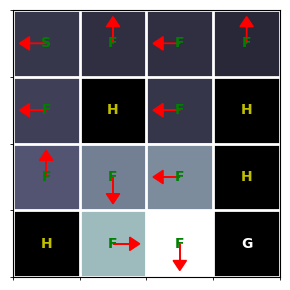

In [4]:
history = value_iteration(mdp, num_iters=1000)
V_star = history[-1]
pi_star = mdp.backup(V_star).argmax(axis=1)
print(f'V*(s0) = {V_star[0]:.4f}')
d2l.show_grid(env.unwrapped.desc, V_star, pi_star)

The values increase from about $0.18$ at the start to $0.72$ beside the goal. On deterministic ice, the shortest route would give the start state value $\gamma^5\approx0.774$; stochastic slips reduce that value by roughly three quarters even under the optimal policy. Several optimal actions point away from the goal. We interpret them below after checking the predicted convergence rate:

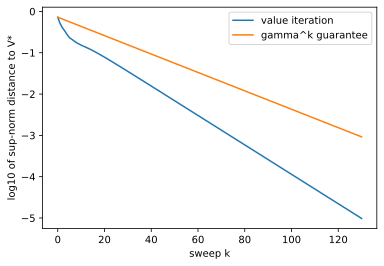

In [5]:
err = np.concatenate([[np.abs(V_star).max()],
                      np.abs(history - V_star).max(axis=1)])
k = np.arange(131)
assert (err[k] <= err[0] * gamma ** k + 1e-12).all()
d2l.plot_curves({'value iteration': np.log10(err[k]),
                 'gamma^k guarantee': np.log10(err[0] * gamma ** k)},
                xlabel='sweep k', ylabel='log10 of sup-norm distance to V*')

On the logarithmic scale, geometric decay appears as a straight line. The guarantee contracts by $\gamma=0.95$ per sweep, whereas the measured error contracts by about $0.92$. The bound reaches $10^{-6}$ at sweep 263, and the measured error reaches it at sweep 158. Thus the discount factor, through the effective horizon, governs the worst-case sweep count; neither the number of cells nor their distance from the goal appears in the contraction rate. An implementation cannot observe the true error and must instead use a stopping criterion:

In [6]:
gap = np.abs(np.diff(history, axis=0)).max(axis=1)
true_err = np.abs(history[1:] - V_star).max(axis=1)
certified = gamma / (1 - gamma) * gap
assert (true_err <= certified + 1e-12).all()
for name, e in [('sweep-to-sweep change', gap),
                ('certified error bound', certified),
                ('distance to V*', true_err)]:
    print(f'{name} first below 1e-6 at sweep {np.argmax(e <= 1e-6) + 2}')
k_cert = np.argmax(certified <= 1e-6) + 2

sweep-to-sweep change first below 1e-6 at sweep 128
certified error bound first below 1e-6 at sweep 164
distance to V* first below 1e-6 at sweep 158


The unadjusted rule $\|V_{k+1}-V_k\|_\infty<10^{-6}$ stops at sweep $128$ but does not directly bound the error to $V^*$. The contraction-based certificate stops at sweep $164$, while the actual error first falls below $10^{-6}$ at sweep $158$. Thus the certified rule is conservative by six sweeps in this example.

### Policy Evaluation

Replace the max in the equation by the policy's own average and the same iteration computes the value of any fixed policy $\pi$:

$$V^\pi_{k+1}(s) = \sum_{a \in \mathcal{A}} \pi(a \mid s) \Big[ r(s, a) + \gamma\ \sum_{s' \in \mathcal{S}} P(s' \mid s, a)\ V^\pi_k(s') \Big];\ \textrm{for all } s \in \mathcal{S}.$$

This is *policy evaluation*, the fixed-point iteration for $T^\pi$, convergent from any initialization because $T^\pi$ contracts too. With the max gone the equations are linear, so they can also be solved directly, as that section did with `np.linalg.solve`; the sweep does the same work one contraction at a time, and is the form that generalizes beyond tables.

In [7]:
def policy_evaluation(mdp, pi, num_iters):
    """Same sweep with the max replaced by an average under pi(a|s)."""
    V, history = np.zeros(mdp.num_states), []
    for _ in range(num_iters):
        V = (pi * mdp.backup(V)).sum(axis=1)
        history.append(V)
    return np.array(history)

uniform = np.ones((mdp.num_states, mdp.num_actions)) / mdp.num_actions
print(f'V(s0) for the uniformly random policy: '
      f'{policy_evaluation(mdp, uniform, 400)[-1][0]:.4f}')

V(s0) for the uniformly random policy: 0.0078


The uniformly random policy of that section reaches the goal in very few episodes. Its start-state value is $0.0078$, about four percent of the optimum. Policy evaluation measures performance without improving the policy; learned critics in that section approximate the same value computation from sampled data.

### Policy Iteration and Generalized Policy Iteration

Evaluation plus the greedy step the equation suggests a different algorithm: evaluate the current policy fully, act greedily on its value function, repeat. The following policy-improvement proposition justifies the greedy step.

**Proposition (policy improvement).** *Let $\pi$ be any policy and let $\pi'$ be greedy with respect to $V^\pi$, that is $\pi'(s) = \mathrm{argmax}_a \big[ r(s, a) + \gamma \sum_{s'} P(s' \mid s, a) V^\pi(s') \big]$. Then $V^{\pi'}(s) \geq V^\pi(s)$ at every state, and if equality holds everywhere then both policies are optimal.*

**Proof.** Greediness says one step of $\pi'$ is at least as good as one step of $\pi$: $T^{\pi'} V^\pi = T V^\pi \geq T^\pi V^\pi = V^\pi$. The operator $T^{\pi'}$ is monotone (its coefficients are probabilities), so $V^\pi \leq T^{\pi'} V^\pi \leq (T^{\pi'})^2 V^\pi \leq \cdots \to V^{\pi'}$, the limit being $T^{\pi'}$'s unique fixed point. If $V^{\pi'} = V^\pi$, the first line reads $TV^\pi = V^\pi$, so $V^\pi$ solves the optimality equation and uniqueness finishes the job. $\blacksquare$

Each round of *policy iteration* therefore strictly improves the policy until it is optimal, and a finite MDP has finitely many deterministic policies, so termination is guaranteed [@Puterman.1994]. The implementation alternates evaluation and improvement until the policy stops changing:

In [8]:
pi, num_outer = uniform, 0
while True:
    V = policy_evaluation(mdp, pi, 800)[-1]                # evaluate pi
    new = np.eye(mdp.num_actions)[mdp.backup(V).argmax(axis=1)]  # improve
    num_outer += 1
    if (new == pi).all():                                  # nothing changed
        break
    pi = new
assert np.abs(V - V_star).max() < 1e-12

The assertion verifies that value iteration and policy iteration agree on $V^*$ to twelve decimal places. Their computational costs, however, are organized differently:

In [9]:
ok = [(mdp.backup(V).argmax(axis=1) == pi_star).all() for V in history]
print(f'policy iteration: {num_outer} rounds of evaluate-then-improve')
print(f'value iteration: certified at sweep {k_cert}')
print(f'its greedy policy already equals pi* from sweep '
      f'{np.argmax(ok) + 1} on')

policy iteration: 2 rounds of evaluate-then-improve
value iteration: certified at sweep 164
its greedy policy already equals pi* from sweep 14 on


Policy iteration requires two improvement rounds on this example, but each round contains 800 evaluation sweeps. Bellman backups therefore provide a more informative comparison than outer iterations. For value iteration, the greedy policy becomes optimal at sweep 14, well before the value-error certificate is satisfied. The policy depends only on the ordering of action values, so it can stabilize before their numerical values have converged.

Policy evaluation and improvement need not be completed in separate phases. *Generalized policy iteration* (GPI) interleaves updates that move $V$ toward $V^\pi$ with updates that move $\pi$ toward a greedy policy [@Sutton.Barto.2018]. Policy iteration performs nearly complete evaluation before improvement, whereas value iteration improves after each sweep. Q-learning uses sampled backups (that section), and actor--critic methods update value and policy estimates together (that section). the figure summarizes these cases.

![Generalized policy iteration. Evaluation, $V = V^\pi$, and greediness, $\pi = \mathrm{greedy}(V)$, hold together only at the optimum, and each algorithm is a discipline for stepping toward both: policy iteration completes each move, value iteration improves after one sweep, Q-learning takes single sampled backups, actor-critic moves along both axes at once.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-gpi.svg)

### The Optimal Policy on Slippery Ice

Although $\pi^*$ maximizes expected return, some of its actions point away from the goal. We evaluate policies by their mean return over sampled episodes without using the transition model:

In [10]:
def evaluate(env, policy, num_episodes, gamma=1.0, rng=None):
    """Mean discounted return of an acting policy over Monte Carlo episodes.

    `policy(obs, rng) -> action` is the protocol every agent in these two
    chapters speaks; a deterministic policy simply ignores `rng`."""
    total = 0.0
    for _ in range(num_episodes):
        obs, done, discount = env.reset()[0], False, 1.0
        while not done:
            obs, reward, terminated, truncated, _ = env.step(policy(obs, rng))
            done = terminated or truncated
            total, discount = total + discount * reward, discount * gamma
    return total / num_episodes

The evaluation protocol represents a policy as a function from observation to action, optionally using an explicit random generator. Later sections use the same interface. With the default $\gamma = 1$ and terminal-only reward, the mean return *is* the success rate. We compare $\pi^*$ with the shortest-path policy derived for deterministic ice:

In [11]:
shortest = np.array([DOWN, RIGHT, DOWN, LEFT,
                     DOWN, LEFT, DOWN, LEFT,
                     RIGHT, DOWN, DOWN, LEFT,
                     LEFT, RIGHT, RIGHT, LEFT])   # optimal on calm ice, by hand
env.reset(seed=0)
for name, p in [('slip-aware optimum', pi_star),
                ('shortest-path policy', shortest)]:
    success = evaluate(env, lambda s, _: int(p[s]), num_episodes=2000)
    print(f'{name}: reaches the goal in {success:.1%} of 2000 episodes')

slip-aware optimum: reaches the goal in 73.6% of 2000 episodes
shortest-path policy: reaches the goal in 4.7% of 2000 episodes


The dynamic-programming policy reaches the goal in about $0.74$ of the episodes, compared with about $0.05$ for the shortest-path policy. These rates count episodes that finish within the environment's 100-step limit; without the limit, the success probability of the optimal policy is about $0.78$. The shortest path places five of its six actions next to holes, where perpendicular slips can terminate the episode. The optimal policy takes a longer route that reduces this risk. The statewise differences are shown below:

In [12]:
row, col = np.arange(16) // 4, np.arange(16) % 4
to_row = np.clip(row + np.array([0, 1, 0, -1])[pi_star], 0, 3)
to_col = np.clip(col + np.array([-1, 0, 1, 0])[pi_star], 0, 3)
frozen = np.isin(env.unwrapped.desc.flatten(), [b'S', b'F'])
away = np.flatnonzero(frozen & ((3 - to_row) + (3 - to_col)
                                > (3 - row) + (3 - col)))
for s in away:
    print(f's={s:>2}: pi* commands {"<v>^"[pi_star[s]]}, '
          f'the shortest path takes {"<v>^"[shortest[s]]}')

s= 2: pi* commands <, the shortest path takes v
s= 6: pi* commands <, the shortest path takes v
s= 8: pi* commands ^, the shortest path takes >
s=10: pi* commands <, the shortest path takes v


At four of the eleven nonterminal frozen cells, the optimal command points away from the goal. At state 8, *up* is the only action whose three possible outcomes all avoid the hole at state 12: the agent moves to state 4, state 9, or remains against the wall. At states 1 and 3, commanding *up* also uses the wall to avoid more dangerous outcomes. These choices follow from averaging over the three transition outcomes in the equation.

**Deterministic case.** Without slippery transitions, $V^*(s)=\gamma V^*(s')$ along an optimal move. Hence $V^*(s)=\gamma^{d(s)-1}$, where $d(s)$ is the shortest distance to the goal. After $k$ sweeps, value has propagated to exactly the states within $k$ moves of the goal, and this map converges in six sweeps (the figure). This finite wavefront is specific to deterministic terminal rewards; the stochastic case converges geometrically. The greedy policy for the deterministic solution is exactly the shortest-path policy, as verified below.

![Value iteration on deterministic FrozenLake, whose values have a closed form. With the slip off, sweep $k$ reaches exactly the cells within $k$ moves of the goal, the orange outline marking the newly reached ones; the value at distance $d$ is $\gamma^{d-1}$. The start cell is six moves away, so its estimate stays at zero for five sweeps and equals $\gamma^5 = 0.774$ from the sixth on.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-value-wavefront.svg)

In [13]:
calm = d2l.TabularMDP.from_gym(
    gym.make('FrozenLake-v1', is_slippery=False), gamma)
V_calm = value_iteration(calm, num_iters=10)[-1]
assert (calm.backup(V_calm).argmax(axis=1) == shortest).all()
print(f'V*(s0) on calm ice: {V_calm[0]:.4f};  gamma^5 = {gamma ** 5:.4f}')

V*(s0) on calm ice: 0.7738;  gamma^5 = 0.7738


The optimal start-state value decreases from $0.774$ on deterministic ice to $0.180$ on slippery ice. This difference quantifies the effect of the stochastic transitions under optimal play.

## Summary

A policy is described by its state and action values, related by $V^\pi(s)=\sum_a\pi(a\mid s)Q^\pi(s,a)$. The Bellman expectation equations characterize a fixed policy, and the Bellman optimality equation characterizes $V^*$. For $\gamma<1$, the optimality operator is a contraction: its fixed point is unique, value iteration converges geometrically, and consecutive iterates give a computable error bound. Policy evaluation replaces maximization by an expectation under a fixed policy. Policy iteration alternates evaluation with greedy improvement, while generalized policy iteration permits partial interleaving. These methods require the transition and reward model; later sections replace exact expectations by sampled transitions.

**Experimental scope.** The value functions, convergence counts, and policies are exact for this MDP at $\gamma=0.95$. The two success rates are Monte Carlo estimates from $2{,}000$ seeded episodes and vary slightly with the seed. The comparison demonstrates the value of planning with the correct stochastic model on this environment; it does not address learning when the model is unknown.

## Exercises

1. [short-code] *Cost of a sweep.* Give the cost of one value iteration sweep
   the equation in terms of the number of states, the number of
   actions, and the number of successors per state-action pair, and say which
   of the three the dense `mdp.backup` of that section actually computes.
   Then use $\|V_k - V^*\|_\infty \leq \gamma^k \|V_0 - V^*\|_\infty$ to show
   that reaching accuracy $\varepsilon$ needs
   $O(\log(1/\varepsilon) / \log(1/\gamma))$ sweeps. Confirm the per-sweep cost
   empirically (a few seconds) by timing the $4 \times 4$ map against the
   $8 \times 8$ map,
   `d2l.TabularMDP.from_gym(gym.make('FrozenLake-v1', map_name='8x8', is_slippery=True), gamma)`.
1. [conceptual] *The contraction, verified.* The section's proposition proved
   $\|TV - TV'\|_\infty \leq \gamma \|V - V'\|_\infty$ using only that a
   maximum of differences bounds the difference of maxima. Re-derive the
   stopping rule
   $\|V_k - V^*\|_\infty \leq \frac{\gamma}{1-\gamma} \|V_k - V_{k-1}\|_\infty$
   from it by telescoping the tail $\sum_{j \geq k} \|V_{j+1} - V_j\|_\infty$,
   and turn it into an $\varepsilon$-optimal stopping rule: how small must the
   sweep-to-sweep change be to guarantee an error below $\varepsilon$? Then walk
   through the proposition's proof with $\gamma = 1$ and point to the exact
   step that fails.
1. [short-code] *Predict, then run.* Before running anything, predict
   $V^*(s_0)$ on the calm map (`is_slippery=False`) for
   $\gamma \in \{0, 0.5, 0.9, 0.99\}$, and predict which of the four optimal
   *policies* differ. Now run value iteration for each and check. Explain in
   one sentence why the value depends on $\gamma$ and the policy does not, and
   what is special about $\gamma = 0$.
1. [short-code] *Let the ice be calm.* The section ran on slippery ice
   throughout. Switch the slip off, rerun value iteration, and compare the two
   optimal policies cell by cell. Which arrows change, and why does
   the equation stop caring about the holes' neighbors
   once $P(s' \mid s, a)$ puts all its mass on the intended cell? The section
   printed $V^*(s_0) = 0.180$ on ice and $0.774$ calm, a ratio of about
   $4.3$: is that larger or smaller than the naive reading "each commanded
   move now succeeds with probability $1/3$" suggests, and what does the
   difference show about how the optimal policy accounts for slips?
1. [conceptual] *When $\gamma$ equals one.* The contraction proposition needs
   $\gamma < 1$, yet running the section's code with $\gamma = 1$ on FrozenLake
   converges. Explain why, using that the goal and the holes are absorbing and
   all rewards are non-negative, and say what the limit $V_k(s)$ means in that
   case. Then construct a two-state MDP with a single action on which $V_k$
   grows without bound at $\gamma = 1$, and verify it in three lines of code.
1. [extended] *Policy iteration measured in backups.* Policy iteration
   converged in $2$ rounds against value iteration's $164$ certified sweeps,
   which suggests a large advantage in outer iterations, but each round contained $800$ evaluation sweeps
   of the equation before the greedy step the equation.
   Measure both algorithms by the number of Bellman backups, and plot the
   sup-norm error against backups on the $4 \times 4$ and $8 \times 8$ maps
   (a few seconds each). Which converges in fewer outer iterations, which in
   fewer backups, and how does the answer move as $\gamma \to 1$? Does
   truncating the inner evaluation to ten sweeps change your accounting?

[Discussions](https://d2l.discourse.group/)